In [4]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
from scipy.interpolate import splev, splprep
from vtkmodules.util import numpy_support as vtknp
from vtkmodules.vtkIOXML import vtkXMLPolyDataReader

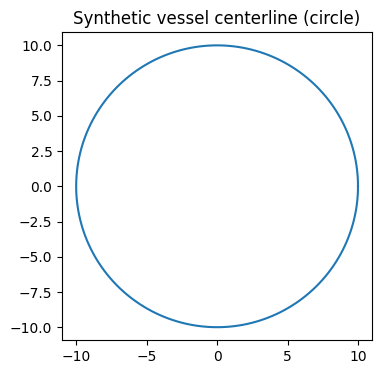

In [6]:
# Verify Centerline
# Circle parameters
R = 10.0
theta = np.linspace(0, 2 * np.pi, 200)

x = R * np.cos(theta)
y = R * np.sin(theta)

pts = np.column_stack([x, y])

plt.figure(figsize=(4, 4))
plt.plot(x, y)
plt.axis("equal")
plt.title("Synthetic vessel centerline (circle)")
plt.show()

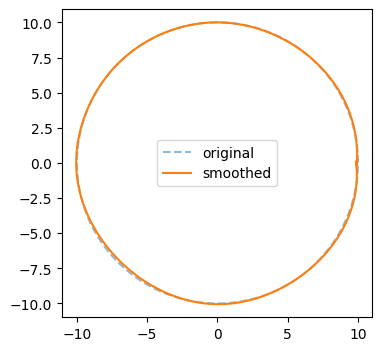

In [7]:
def arclength_param(pts: NDArray[np.floating]) -> NDArray[np.floating]:
    """Compute cumulative arclength parameterization of a polyline.

    Parameters
    ----------
    pts : (N, d) array
        Sequence of points defining the curve.

    Returns:
    -------
    s : (N,) array
        Cumulative arclength parameter.
    """
    diffs = np.diff(pts, axis=0)
    seg_lengths = np.linalg.norm(diffs, axis=1)
    s = np.concatenate([[0], np.cumsum(seg_lengths)])
    return s


s = arclength_param(pts)


# Fit parametric spline x(s), y(s)
tck, _ = splprep([pts[:, 0], pts[:, 1]], s=1.0)
x_s, y_s = splev(np.linspace(0, 1, len(pts)), tck)

pts_smooth = np.column_stack([x_s, y_s])

plt.figure(figsize=(4, 4))
plt.plot(pts[:, 0], pts[:, 1], "--", alpha=0.5, label="original")
plt.plot(pts_smooth[:, 0], pts_smooth[:, 1], label="smoothed")
plt.axis("equal")
plt.legend()
plt.show()

In [10]:
dx = np.gradient(x_s, s)
dy = np.gradient(y_s, s)

ddx = np.gradient(dx, s)
ddy = np.gradient(dy, s)

curvature = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2) ** 1.5

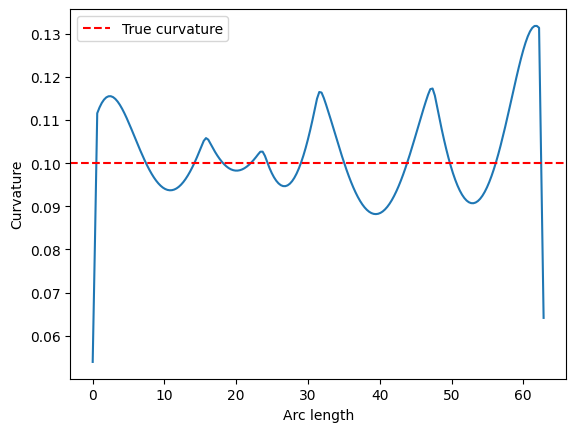

Mean curvature: 0.10201580895622672
Expected curvature: 0.1


In [11]:
plt.figure()
plt.plot(s, curvature)
plt.axhline(1 / R, color="red", linestyle="--", label="True curvature")
plt.xlabel("Arc length")
plt.ylabel("Curvature")
plt.legend()
plt.show()

print("Mean curvature:", np.mean(curvature))
print("Expected curvature:", 1 / R)

In [15]:
def load_centerline_points(vtp_file: str) -> np.ndarray:
    """Load points from VTK PolyData file (.vtp or .vtk)."""
    reader = vtkXMLPolyDataReader()
    reader.SetFileName(vtp_file)
    reader.Update()
    poly = reader.GetOutput()

    points = vtknp.vtk_to_numpy(poly.GetPoints().GetData())
    print(f"Loaded {len(points)} points from {vtp_file}")
    return points

In [16]:
MIN_POINTS = 3


def calculate_curvature_from_polyline(points: np.ndarray) -> np.ndarray:
    """Calculate curvature at each point using tangent vector method.

    Method: |dT/ds| where T is tangent vector, s is arc-length
    """
    if len(points) < MIN_POINTS:
        return np.zeros(len(points))

    # Compute tangent vectors
    diffs = np.diff(points, axis=0)
    ds = np.linalg.norm(diffs, axis=1, keepdims=True)
    ds = np.maximum(ds, 1e-6)  # Avoid division by zero
    tangents = diffs / ds

    # Compute curvature as change in tangent direction
    dT = np.diff(tangents, axis=0)
    ds_mid = (ds[:-1] + ds[1:]) / 2.0
    ds_mid = np.maximum(ds_mid, 1e-6)
    curvature = np.linalg.norm(dT, axis=1) / ds_mid.flatten()

    # Pad to match number of points (curvature undefined at endpoints)
    curvature_full = np.zeros(len(points))
    curvature_full[1:-1] = curvature

    return curvature_full

Testing curvature calculation on synthetic circle centerline...


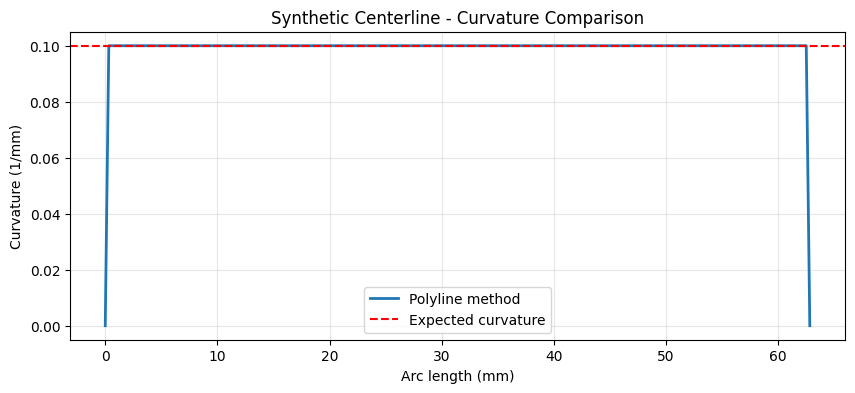

Mean curvature (polyline): 0.1000 1/mm
Expected curvature: 0.1000 1/mm

USING GRAPH-PRUNING (NUMBA-BASED) APPROACH

✓ Confirmed: Using Numba-based centerline extraction
  - Source: graph_pruning_centerline_extraction/skeleton3d_utils/
  - Output format: JSON files with morphometry data
  - Files: *_morphometry.json

LOADING CURVATURE DATA FROM JSON

Loading: /net/projects2/vanguard/vessel_segmentations/processed_3D/DUKE_134_DUKE_134_0004_vessel_segmentation_morphometry.json

------------------------------------------------------------
VESSEL CURVATURE STATISTICS
------------------------------------------------------------

------------------------------------------------------------
✓ Successfully loaded curvature data from JSON!


In [19]:
# Test with synthetic centerline first
print("Testing curvature calculation on synthetic circle centerline...")

# Recreate synthetic circle for testing (in case earlier cells weren't run)
R_test = 10.0
theta_test = np.linspace(0, 2 * np.pi, 200)
x_test = R_test * np.cos(theta_test)
y_test = R_test * np.sin(theta_test)
pts_test = np.column_stack([x_test, y_test])

# Calculate curvature using polyline method on the synthetic circle
curvature_polyline = calculate_curvature_from_polyline(pts_test)

# Calculate arc-length for x-axis
s_synthetic = arclength_param(pts_test)

# Plot results
plt.figure(figsize=(10, 4))
plt.plot(s_synthetic, curvature_polyline, linewidth=2, label="Polyline method")
plt.axhline(1 / R_test, color="red", linestyle="--", label="Expected curvature")
plt.xlabel("Arc length (mm)")
plt.ylabel("Curvature (1/mm)")
plt.title("Synthetic Centerline - Curvature Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean curvature (polyline): {np.mean(curvature_polyline[1:-1]):.4f} 1/mm")
print(f"Expected curvature: {1/R_test:.4f} 1/mm")
print("\n" + "=" * 60)
print("USING GRAPH-PRUNING (NUMBA-BASED) APPROACH")
print("=" * 60)
print("\n✓ Confirmed: Using Numba-based centerline extraction")
print("  - Source: graph_pruning_centerline_extraction/skeleton3d_utils/")
print("  - Output format: JSON files with morphometry data")
print("  - Files: *_morphometry.json")
print("\n" + "=" * 60)
print("LOADING CURVATURE DATA FROM JSON")
print("=" * 60)

# Load and display curvature from Graph-Pruning morphometry JSON
try:
    import json
    
    # Update this path to point to your *_morphometry.json file
    json_file = "/net/projects2/vanguard/vessel_segmentations/processed_3D/DUKE_134_DUKE_134_0004_vessel_segmentation_morphometry.json"

    print(f"\nLoading: {json_file}")
    with open(json_file) as f:
        data = json.load(f)
    
    # Extract and display curvature for each vessel
    print("\n" + "-" * 60)
    print("VESSEL CURVATURE STATISTICS")
    print("-" * 60)
    
    for vessel_id, vessel_data in data.items():
        curvature_stats = vessel_data.get("curvature", {})
        if curvature_stats:
            print(f"\nVessel {vessel_id}:")
            print(f"  Mean curvature:   {curvature_stats.get('mean', 'N/A')} 1/mm")
            print(f"  Std deviation:    {curvature_stats.get('sd', 'N/A')} 1/mm")
            print(f"  Median curvature: {curvature_stats.get('median', 'N/A')} 1/mm")
            print(f"  Min curvature:    {curvature_stats.get('min', 'N/A')} 1/mm")
            print(f"  Max curvature:    {curvature_stats.get('max', 'N/A')} 1/mm")
            
            # Also show radius and tortuosity if available
            radius_stats = vessel_data.get("radius", {})
            if radius_stats:
                print(f"  Mean radius:      {radius_stats.get('mean', 'N/A')} mm")
            
            tortuosity = vessel_data.get("tortuosity", "N/A")
            if tortuosity != "N/A":
                print(f"  Tortuosity:       {tortuosity}")
    
    print("\n" + "-" * 60)
    print("✓ Successfully loaded curvature data from JSON!")
    
except FileNotFoundError:
    print(f"\n❌ File not found: {json_file}")
    print("\nTo proceed:")
    print("1. Find the *_morphometry.json files from graph_pruning_centerline_extraction")
    print("2. Ask your advisor where they are stored")
    print("3. Update the json_file path above")
    print("4. Re-run this cell")
except json.JSONDecodeError as e:
    print(f"\n❌ Error parsing JSON: {e}")
except KeyError as e:
    print(f"\n⚠ Unexpected JSON structure - key missing: {e}")
    print("Check that the file is from graph-pruning centerline extraction")